#  Data Cleaning & Model Training — Appartements Vente Marrakech



##  Imports

In [1]:
import os
import sys
import json
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

warnings.filterwarnings("ignore")

# Ajouter le dossier pipeline au path
sys.path.append(os.path.abspath("../../pipeline"))

print(" Imports OK")


 Imports OK


## 1. Chargement du fichier brut

In [2]:
RAW_PATH     = "../../data/marrakech_immo_vente/appartement_vente.csv"
CLEAN_PATH   = "../../data/cleaned_data/vente/appartement_vente_final.csv"
MODEL_PATH   = "../../model_training/models/xgb_appartement_vente.pkl"
META_PATH    = "../../model_training/models/xgb_appartement_vente_metadata.json"

df = pd.read_csv(RAW_PATH)
print(f"Shape initiale : {df.shape}")
print(f"Colonnes : {df.columns.tolist()}")
df.head(3)


Shape initiale : (6387, 34)
Colonnes : ['id', 'titre', 'prix', 'localisation', 'type_bien', 'surface', 'chambres', 'salles_bain', 'description', 'agence', 'url', 'source', 'piscine', 'parking', 'ascenseur', 'terrasse', 'jardin', 'climatisation', 'securite', 'vue', 'meuble', 'neuf', 'cave', 'hammam', 'etage', 'surface_terrain', 'prix_num', 'surface_num', 'chambres_num', 'salles_bain_num', 'nb_pieces', 'quartier', 'prix_m2', 'prix_m2_median_quartier']


,id,titre,prix,localisation,type_bien,surface,chambres,salles_bain,description,agence,...,etage,surface_terrain,prix_num,surface_num,chambres_num,salles_bain_num,nb_pieces,quartier,prix_m2,prix_m2_median_quartier
0,8257819.0,Appartement à l'achat à Guéliz. 1 belle chambre,998 000 DH,"Guéliz, Marrakech",Appartement,58 m²,1 Chambre,1 Salle de bain,FLOREA est une résidence contemporaine située ...,Particulier,...,-1,NaN,998000.0,58.0,1.0,1.0,3.0,Guéliz,17206.896552,18180.000000
1,7921912.0,Affaire à saisir: Appartement 1 chambre à Guéliz,1 368 000 DH,"Guéliz, Marrakech",Appartement,54 m²,1 Chambre,2 Salles de bains,Ne manquez pas cette opportunité ! Nous vous p...,Particulier,...,-1,NaN,1368000.0,54.0,1.0,2.0,2.0,Guéliz,25333.333333,18180.000000
2,8235678.0,Appartement 125 m² à vendre à Hivernage,275 000 EUR,"Hivernage, Marrakech",Appartement,125 m²,2 Chambres,2 Salles de bains,"Lunel Résidence d’exception à l’Hivernage, Mar...",Particulier,...,-1,NaN,275000.0,125.0,2.0,2.0,5.0,Hivernage,2200.000000,20871.212121


## 2. Cleaning

Étapes appliquées :
1. Conversion EUR → MAD
2. Suppression lignes sans target
3. Filtrage surface (0–500 m²)
4. Filtrage prix/m² (4 000–60 000 MAD/m²)
5. Suppression outliers prix (percentile 1–99 sur log-échelle)
6. Nettoyage étage, chambres, salles de bain

In [3]:
EUR_TO_MAD = 10.8

# 1. Conversion EUR → MAD
eur_mask = df["prix"].str.contains("EUR", na=False)
df.loc[eur_mask, "prix_num"] = df.loc[eur_mask, "prix_num"] * EUR_TO_MAD
print(f"EUR → MAD convertis : {eur_mask.sum()} lignes")

# 2. Suppression lignes sans target
before = len(df)
df = df[df["prix_num"].notna() & (df["prix_num"] > 0)].copy()
print(f"Supprimés (prix null/zero)     : {before - len(df)}")

# 3. Filtrage surface aberrante
before = len(df)
df = df[df["surface_num"].notna() & (df["surface_num"] > 0) & (df["surface_num"] <= 500)].copy()
print(f"Supprimés (surface aberrante)  : {before - len(df)}")

# 4. Filtrage prix/m² aberrant
df["_prix_m2"] = df["prix_num"] / df["surface_num"]
before = len(df)
df = df[(df["_prix_m2"] >= 4_000) & (df["_prix_m2"] <= 60_000)].copy()
print(f"Supprimés (prix/m² aberrant)   : {before - len(df)}")
df.drop(columns=["_prix_m2"], inplace=True)

# 5. Outliers prix (log-échelle, percentile 1-99)
log_prix = np.log(df["prix_num"])
before = len(df)
df = df[(log_prix >= log_prix.quantile(0.01)) & (log_prix <= log_prix.quantile(0.99))].copy()
print(f"Supprimés (outliers prix)      : {before - len(df)}")

# 6. Etage : -1 → NaN + flag binaire
df["etage"] = df["etage"].replace(-1, np.nan)
df["etage_known"] = df["etage"].notna().astype(int)
df["etage"] = df["etage"].fillna(-99)

# 7. Chambres
df["chambres_num"] = df["chambres_num"].replace(0, np.nan)
df.loc[df["chambres_num"] > 10, "chambres_num"] = np.nan
df["chambres_num"] = df["chambres_num"].fillna(df["chambres_num"].median())

# 8. Salles de bain
df["salles_bain_num"] = df["salles_bain_num"].fillna(df["salles_bain_num"].median())

print(f"\n Shape après cleaning : {df.shape}")
print(f"   Valeurs manquantes   : {df.isnull().sum().sum()}")


EUR → MAD convertis : 92 lignes
Supprimés (prix null/zero)     : 718
Supprimés (surface aberrante)  : 132
Supprimés (prix/m² aberrant)   : 259
Supprimés (outliers prix)      : 100

 Shape après cleaning : (5178, 35)
   Valeurs manquantes   : 12623


## 3. Feature Engineering

In [4]:
# Quartier clean (top 8 + Autre)
top_quartiers = df["quartier"].value_counts().index[:8]
df["quartier_clean"] = df["quartier"].apply(lambda x: x if x in top_quartiers else "Autre")

# Localisation fine (premier segment de la colonne localisation)
df["localisation_fine"] = (
    df["localisation"]
    .str.split(",").str[0]
    .str.strip().str.lower()
    .str.replace(r"[^a-zàâäéèêëîïôùûü '\-]", "", regex=True)
)
counts = df["localisation_fine"].value_counts()
zones_valides = counts[counts >= 10].index
df["localisation_fine"] = df["localisation_fine"].apply(
    lambda x: x if x in zones_valides else "autre_zone"
)
print(f"Zones localisation retenues : {df['localisation_fine'].nunique()}")

# Features numériques dérivées
df["surface_par_chambre"]  = df["surface_num"] / df["chambres_num"].clip(lower=1)
df["score_standing"]       = df[["piscine","terrasse","vue","hammam","climatisation","securite"]].sum(axis=1)
df["nb_equipements"]       = df[["piscine","parking","ascenseur","terrasse","jardin",
                                  "climatisation","securite","vue","cave","hammam"]].sum(axis=1)

q_median = df.groupby("quartier_clean")["prix_num"].transform("median")
df["surface_x_quartier"]   = df["surface_num"] * q_median / 1e6

q_mean = df.groupby("quartier_clean")["prix_num"].transform("mean")
df["prix_m2_moy_quartier"] = q_mean / df["surface_num"]

q_surf = df.groupby("quartier_clean")["surface_num"].transform("mean")
df["surface_relative"]     = df["surface_num"] / q_surf

# Target log-transformé
df["log_prix"] = np.log(df["prix_num"])

print(f" Shape finale : {df.shape}")
print(f"   Nouvelles features : surface_par_chambre, score_standing, nb_equipements,")
print(f"                        surface_x_quartier, prix_m2_moy_quartier, surface_relative")


Zones localisation retenues : 67
 Shape finale : (5178, 44)
   Nouvelles features : surface_par_chambre, score_standing, nb_equipements,
                        surface_x_quartier, prix_m2_moy_quartier, surface_relative


## 4. Visualisation rapide

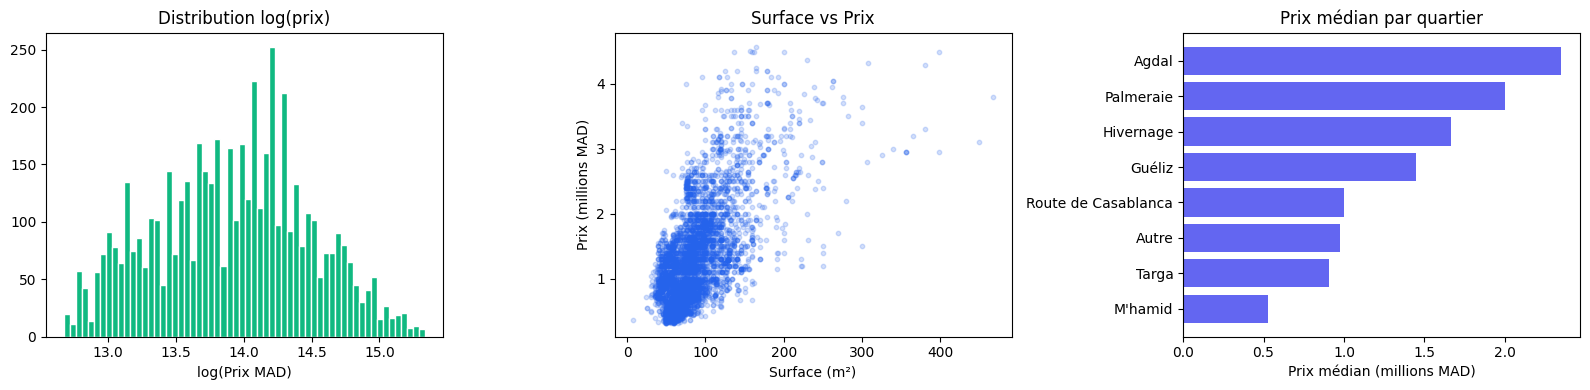


Prix médian par quartier :
                     Médiane (MAD)     N
quartier_clean                          
Agdal                    2350000.0   148
Palmeraie                2000000.0    98
Hivernage                1662500.0   174
Guéliz                   1450000.0  1240
Route de Casablanca      1000000.0   233
Autre                     976500.0  2836
Targa                     910000.0   158
M'hamid                   530000.0   291


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution log(prix)
axes[0].hist(df["log_prix"], bins=60, color="#10B981", edgecolor="white")
axes[0].set_title("Distribution log(prix)")
axes[0].set_xlabel("log(Prix MAD)")

# Surface vs Prix
axes[1].scatter(df["surface_num"], df["prix_num"]/1e6, alpha=0.2, s=10, color="#2563EB")
axes[1].set_xlabel("Surface (m²)")
axes[1].set_ylabel("Prix (millions MAD)")
axes[1].set_title("Surface vs Prix")

# Prix médian par quartier
med = df.groupby("quartier_clean")["prix_num"].median().sort_values(ascending=True) / 1e6
axes[2].barh(med.index, med.values, color="#6366F1")
axes[2].set_xlabel("Prix médian (millions MAD)")
axes[2].set_title("Prix médian par quartier")

plt.tight_layout()
plt.show()

print("\nPrix médian par quartier :")
print(df.groupby("quartier_clean")["prix_num"]
        .agg(["median","count"])
        .sort_values("median", ascending=False)
        .rename(columns={"median":"Médiane (MAD)","count":"N"}))


## 5. Séparation features / target + train/test split

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

NUMERIC_FEATURES = [
    "surface_num", "chambres_num", "salles_bain_num", "etage", "etage_known",
    "surface_par_chambre", "score_standing", "surface_x_quartier",
    "prix_m2_moy_quartier", "surface_relative", "nb_equipements",
]
BINARY_FEATURES = [
    "piscine","parking","ascenseur","terrasse","jardin","climatisation",
    "securite","vue","meuble","neuf","cave","hammam",
]
CATEGORICAL_FEATURES = ["quartier_clean", "localisation_fine"]
TARGET_LOG = "log_prix"

all_features = NUMERIC_FEATURES + BINARY_FEATURES + CATEGORICAL_FEATURES
X = df[all_features].copy()
y = df[TARGET_LOG].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Split effectué")
print(f"   Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")
print(f"   Features : {X.shape[1]}")


 Split effectué
   Train : 4142 lignes | Test : 1036 lignes
   Features : 25


## 6. Preprocessor sklearn

In [7]:
import category_encoders as ce
preprocessor = ColumnTransformer([
    ("num", StandardScaler(),                                              NUMERIC_FEATURES),
    ("bin", "passthrough",                                                 BINARY_FEATURES),
    ("cat", ce.TargetEncoder(),   CATEGORICAL_FEATURES),
], remainder="drop")

# Fit sur X_train uniquement (évite le data leakage)
preprocessor.fit(X_train, y_train)
print(" Preprocessor fitté sur X_train")


 Preprocessor fitté sur X_train


## 7. Optimisation des hyperparamètres avec Optuna



In [8]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 500, 2000),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth"       : trial.suggest_int("max_depth", 4, 9),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha"       : trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda"      : trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "gamma"           : trial.suggest_float("gamma", 0, 3),
    }
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(**params, random_state=42, n_jobs=-1)),
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300, show_progress_bar=True)

print(f"\n Meilleur R² CV : {study.best_value:.4f}")
print("Meilleurs hyperparamètres :")
for k, v in study.best_params.items():
    print(f"  {k:25s} : {v}")


Best trial: 99. Best value: 0.788184: 100%|██████████| 100/100 [01:43<00:00,  1.03s/it]


 Meilleur R² CV : 0.7882
Meilleurs hyperparamètres :
  n_estimators              : 938
  learning_rate             : 0.04786443142949678
  max_depth                 : 6
  subsample                 : 0.8909903874773909
  colsample_bytree          : 0.8839826559890444
  min_child_weight          : 3
  reg_alpha                 : 0.030867789701680037
  reg_lambda                : 4.593187959680031
  gamma                     : 0.07300130946362801


## 8. Entraînement du modèle final

In [9]:
pipeline_final = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(**study.best_params, random_state=42, n_jobs=-1)),
])
pipeline_final.fit(X_train, y_train)
print(" Modèle entraîné")


 Modèle entraîné


## 9. Évaluation

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, KFold

log_pred   = pipeline_final.predict(X_test)
y_pred_mad = np.exp(log_pred)
y_true_mad = np.exp(y_test.values)

mae  = mean_absolute_error(y_true_mad, y_pred_mad)
rmse = np.sqrt(mean_squared_error(y_true_mad, y_pred_mad))
r2   = r2_score(y_true_mad, y_pred_mad)
mape = np.mean(np.abs((y_true_mad - y_pred_mad) / y_true_mad)) * 100

kf    = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(pipeline_final, X_train, y_train, cv=kf, scoring="r2")

print("\n" + "═" * 45)
print("  MÉTRIQUES D'ÉVALUATION")
print("═" * 45)
print(f"  MAE              : {mae:>15,.0f} MAD")
print(f"  RMSE             : {rmse:>15,.0f} MAD")
print(f"  R²               : {r2:>15.4f}")
print(f"  MAPE             : {mape:>14.2f} %")
print(f"  CV R² (5 folds)  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print("═" * 45)

metrics_final = {
    "R²": r2, "MAE (MAD)": mae, "RMSE (MAD)": rmse, "MAPE (%)": mape,
    "CV R² (mean)": cv_r2.mean(), "CV R² (std)": cv_r2.std(),
}



═════════════════════════════════════════════
  MÉTRIQUES D'ÉVALUATION
═════════════════════════════════════════════
  MAE              :         253,397 MAD
  RMSE             :         402,785 MAD
  R²               :          0.7228
  MAPE             :          19.35 %
  CV R² (5 folds)  : 0.7915 ± 0.0107
═════════════════════════════════════════════


## 10. Visualisations du modèle

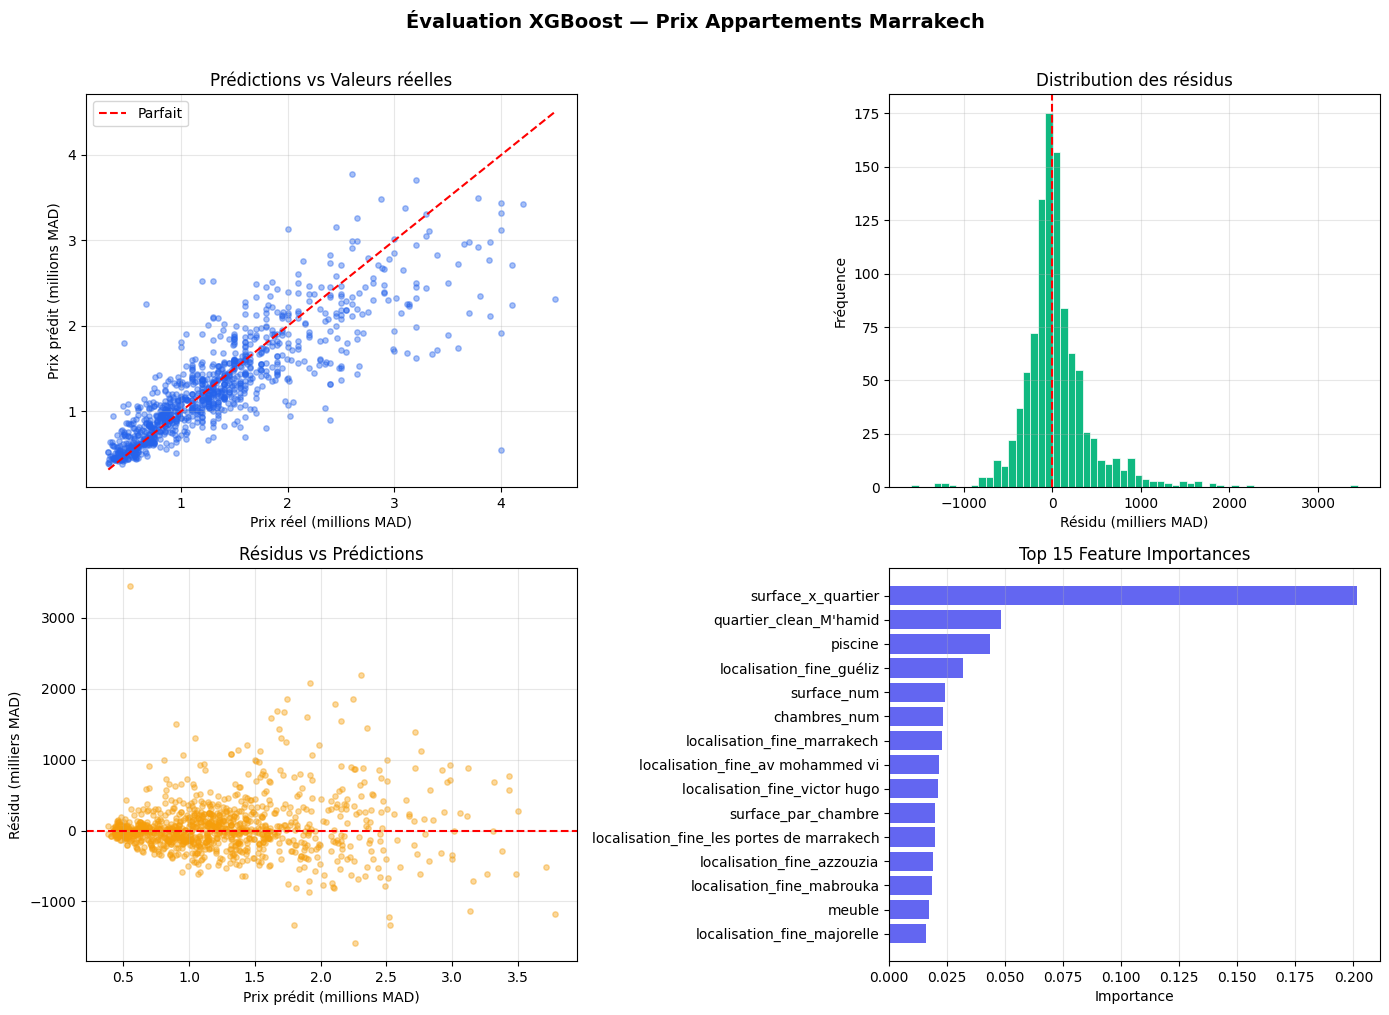

 Graphiques sauvegardés → model_evaluation.png


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Évaluation XGBoost — Prix Appartements Marrakech",
             fontsize=14, fontweight="bold", y=1.01)

residuals = y_true_mad - y_pred_mad

# 1. Prédictions vs Réel
ax = axes[0, 0]
ax.scatter(y_true_mad/1e6, y_pred_mad/1e6, alpha=0.4, s=15, color="#2563EB")
lims = [min(y_true_mad.min(), y_pred_mad.min())/1e6,
        max(y_true_mad.max(), y_pred_mad.max())/1e6]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Parfait")
ax.set_xlabel("Prix réel (millions MAD)"); ax.set_ylabel("Prix prédit (millions MAD)")
ax.set_title("Prédictions vs Valeurs réelles"); ax.legend(); ax.grid(True, alpha=0.3)

# 2. Distribution des résidus
ax = axes[0, 1]
ax.hist(residuals/1e3, bins=60, color="#10B981", edgecolor="white", linewidth=0.5)
ax.axvline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Résidu (milliers MAD)"); ax.set_ylabel("Fréquence")
ax.set_title("Distribution des résidus"); ax.grid(True, alpha=0.3)

# 3. Résidus vs Prédictions
ax = axes[1, 0]
ax.scatter(y_pred_mad/1e6, residuals/1e3, alpha=0.4, s=15, color="#F59E0B")
ax.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Prix prédit (millions MAD)"); ax.set_ylabel("Résidu (milliers MAD)")
ax.set_title("Résidus vs Prédictions"); ax.grid(True, alpha=0.3)

# 4. Feature Importance
ax = axes[1, 1]
try:
    num_names = list(preprocessor.transformers_[0][2])
    bin_names = list(preprocessor.transformers_[1][2])
    cat_enc   = preprocessor.transformers_[2][1]
    cat_names = list(cat_enc.get_feature_names_out(CATEGORICAL_FEATURES))
    feature_names = num_names + bin_names + cat_names
except Exception:
    feature_names = [f"f{i}" for i in range(pipeline_final.named_steps["model"].n_features_in_)]

importances = pipeline_final.named_steps["model"].feature_importances_
top_n = min(15, len(feature_names))
idx   = np.argsort(importances)[-top_n:]
ax.barh([feature_names[i] for i in idx], importances[idx], color="#6366F1")
ax.set_xlabel("Importance"); ax.set_title(f"Top {top_n} Feature Importances")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig("model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Graphiques sauvegardés → model_evaluation.png")


## 11. Analyse des erreurs par quartier

In [12]:
erreur_pct = np.abs((y_true_mad - y_pred_mad) / y_true_mad) * 100

df_test = X_test.copy()
df_test["prix_reel"]   = y_true_mad
df_test["prix_predit"] = y_pred_mad
df_test["erreur_pct"]  = erreur_pct

print("=== MAPE par quartier ===")
print(df_test.groupby("quartier_clean")["erreur_pct"]
      .agg(["mean","count"]).sort_values("mean", ascending=False).round(1))

print("\n=== Distribution erreur % ===")
for seuil in [10, 20, 30, 50]:
    pct = (erreur_pct <= seuil).mean() * 100
    print(f"  Erreur <= {seuil:2d}% : {pct:.1f}% des cas")


=== MAPE par quartier ===
                     mean  count
quartier_clean                  
Palmeraie            29.2     17
Agdal                21.1     35
Autre                20.6    553
Targa                19.3     26
Hivernage            18.3     37
Guéliz               18.1    267
Route de Casablanca  15.8     56
M'hamid              12.0     45

=== Distribution erreur % ===
  Erreur <= 10% : 37.7% des cas
  Erreur <= 20% : 65.4% des cas
  Erreur <= 30% : 81.4% des cas
  Erreur <= 50% : 93.6% des cas


## 12. Sauvegarde du modèle et du dataset final

In [13]:
# Créer les dossiers si absents
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)
os.makedirs(os.path.dirname(CLEAN_PATH), exist_ok=True)

# Modèle
joblib.dump(pipeline_final, MODEL_PATH)
print(f" Modèle sauvegardé       → {MODEL_PATH}")

# Métadonnées
metadata = {
    "date"           : datetime.now().strftime("%Y-%m-%d"),
    "modele"         : "XGBRegressor",
    "n_lignes_train" : len(X_train),
    "n_lignes_test"  : len(X_test),
    "n_features"     : X_train.shape[1],
    "features"       : list(X_train.columns),
    "metriques_test" : {
        "R2"   : round(metrics_final["R²"], 4),
        "MAE"  : round(metrics_final["MAE (MAD)"], 0),
        "RMSE" : round(metrics_final["RMSE (MAD)"], 0),
        "MAPE" : round(metrics_final["MAPE (%)"], 2),
    },
    "hyperparametres": study.best_params,
}
with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)
print(f" Métadonnées sauvegardées → {META_PATH}")

# Dataset final
df.to_csv(CLEAN_PATH, index=False)
print(f" Dataset final sauvegardé → {CLEAN_PATH}")

# Résumé
print("\n" + "═" * 50)
print("  RÉSUMÉ FINAL")
print("═" * 50)
print(f"  Données           : {len(df):,} appartements")
print(f"  Features          : {X_train.shape[1]}")
print(f"  R² (test)         : {metrics_final['R²']:.4f}")
print(f"  MAE (test)        : {metrics_final['MAE (MAD)']:,.0f} MAD")
print(f"  MAPE (test)       : {metrics_final['MAPE (%)']:.2f} %")
print(f"  CV R² (5 folds)   : {cv_r2.mean():.4f}")
print("═" * 50)
print(f"\n  → Erreur moyenne : ±{metrics_final['MAE (MAD)']:,.0f} MAD")
print(f"  → Soit           : ±{metrics_final['MAPE (%)']:.0f}% du prix réel")
print(f"  → Variance exp.  : {metrics_final['R²']*100:.1f}%")


 Modèle sauvegardé       → ../../model_training/models/xgb_appartement_vente.pkl
 Métadonnées sauvegardées → ../../model_training/models/xgb_appartement_vente_metadata.json
 Dataset final sauvegardé → ../../data/cleaned_data/vente/appartement_vente_final.csv

══════════════════════════════════════════════════
  RÉSUMÉ FINAL
══════════════════════════════════════════════════
  Données           : 5,178 appartements
  Features          : 25
  R² (test)         : 0.7228
  MAE (test)        : 253,397 MAD
  MAPE (test)       : 19.35 %
  CV R² (5 folds)   : 0.7915
══════════════════════════════════════════════════

  → Erreur moyenne : ±253,397 MAD
  → Soit           : ±19% du prix réel
  → Variance exp.  : 72.3%


## 13. Exemple de prédiction sur un nouvel appartement

In [14]:
exemple = {
    "surface_num"         : 85,
    "chambres_num"        : 2,
    "salles_bain_num"     : 1,
    "etage"               : 3,
    "etage_known"         : 1,
    "surface_par_chambre" : 85 / 2,
    "score_standing"      : 2,
    "surface_x_quartier"  : 85 * 1_400_000 / 1e6,
    "prix_m2_moy_quartier": 1_400_000 / 85,
    "surface_relative"    : 1.0,
    "nb_equipements"      : 3,
    "piscine"        : 0, "parking"       : 1, "ascenseur" : 1,
    "terrasse"       : 0, "jardin"         : 0, "climatisation": 1,
    "securite"       : 1, "vue"            : 0, "meuble"    : 0,
    "neuf"           : 0, "cave"           : 0, "hammam"    : 0,
    "quartier_clean"    : "Guéliz",
    "localisation_fine" : "guéliz",
}

df_exemple = pd.DataFrame([exemple])
log_pred   = pipeline_final.predict(df_exemple)[0]
prix_mad   = np.exp(log_pred)

print(f" Prix estimé : {prix_mad:,.0f} MAD")
print(f"   ≈ {prix_mad/10.8:,.0f} EUR")
print(f"   ≈ {prix_mad/85:,.0f} MAD/m²")


 Prix estimé : 1,287,563 MAD
   ≈ 119,219 EUR
   ≈ 15,148 MAD/m²
